In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import io
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# Load FX data
def query_athena(query, database='fx_rates_db', region='us-east-2'):
    athena = boto3.client('athena', region_name=region)
    s3 = boto3.client('s3', region_name=region)
    output_location = 's3://fx-rates-ninpar/athena-results/'
    
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': output_location}
    )
    query_id = response['QueryExecutionId']
    
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state = status['QueryExecution']['Status']['State']
        if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
            break
        time.sleep(1)
    
    if state != 'SUCCEEDED':
        raise Exception(f"Query failed")
    
    result_location = status['QueryExecution']['ResultConfiguration']['OutputLocation']
    bucket = result_location.split('/')[2]
    key = '/'.join(result_location.split('/')[3:])
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

df_fx = query_athena("""
    SELECT date, rates.inr AS usd_inr, rates.eur AS usd_eur, 
           rates.gbp AS usd_gbp, rates.mxn AS usd_mxn, rates.php AS usd_php
    FROM fx_rates_db.usd
    ORDER BY date ASC
""")
df_fx['date'] = pd.to_datetime(df_fx['date'])
df_fx = df_fx.set_index('date').sort_index()

# Load macro features from notebook 06
macro = pd.read_csv('macro_features.csv', index_col='date', parse_dates=True)

print(f"FX data: {len(df_fx)} days")
print(f"Macro features: {macro.shape}")

FX data: 281 days
Macro features: (281, 28)


In [6]:
def engineer_fx_features(rate_series, name):
    """
    Create FX-specific features for a single currency pair.
    Uses shorter rolling windows to maximize usable rows given 281-day dataset.
    """
    features = pd.DataFrame(index=rate_series.index)
    returns = rate_series.pct_change()
    
    # Lagged returns (recent momentum)
    for lag in [1, 2, 3, 5, 10]:
        features[f'{name}_return_lag{lag}'] = returns.shift(lag)
    
    # Multi-day returns
    for window in [5, 10, 20]:
        features[f'{name}_return_{window}d'] = rate_series.pct_change(window)
    
    # Volatility features
    for window in [5, 10, 20]:
        features[f'{name}_vol_{window}d'] = returns.rolling(window).std()
    
    # Bollinger %B using EWMA (single 30-day window)
    for window in [30]:
        ewma_mean = rate_series.ewm(span=window).mean()
        ewma_std = rate_series.ewm(span=window).std()
        upper = ewma_mean + 2 * ewma_std
        lower = ewma_mean - 2 * ewma_std
        features[f'{name}_pctb_{window}'] = (rate_series - lower) / (upper - lower)
    
    # Z-score (where is rate vs recent average)
    for window in [30]:
        features[f'{name}_zscore_{window}'] = (
            (rate_series - rate_series.rolling(window).mean()) / 
            rate_series.rolling(window).std()
        )
    
    return features

# Build feature sets for each pair
fx_features_by_pair = {}
for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    fx_features_by_pair[col] = engineer_fx_features(df_fx[col], col)
    print(f"{col.upper()}: {fx_features_by_pair[col].shape[1]} FX-specific features")

USD_INR: 13 FX-specific features
USD_EUR: 13 FX-specific features
USD_GBP: 13 FX-specific features
USD_MXN: 13 FX-specific features
USD_PHP: 13 FX-specific features


In [10]:
def build_dataset(pair, fx_features, macro_features, target_pair):
    """
    Combine FX-specific and macro features.
    Drop us_cpi (monthly, mostly NaN at daily frequency).
    """
    df = pd.concat([fx_features, macro_features], axis=1)
    
    # Drop us_cpi — monthly data, 98% NaN at daily frequency
    if 'us_cpi' in df.columns:
        df = df.drop(columns=['us_cpi'])
    
    # Map pair to country
    country_map = {
        'usd_inr': 'india',
        'usd_eur': 'eurozone',
        'usd_gbp': 'uk',
        'usd_mxn': 'mexico',
        'usd_php': 'philippines'
    }
    country = country_map[pair]
    diff_col = f'us_{country}_rate_diff'
    
    if diff_col in df.columns:
        df[f'{diff_col}_change_30d'] = df[diff_col].diff(30)
    
    df['target'] = (target_pair.shift(-1) > target_pair).astype(int)
    
    return df

datasets = {}
for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    datasets[col] = build_dataset(col, fx_features_by_pair[col], macro, df_fx[col])
    
    before = len(datasets[col])
    datasets[col] = datasets[col].dropna()
    after = len(datasets[col])
    
    print(f"{col.upper()}: {datasets[col].shape[1] - 1} features, {after} usable rows (dropped {before - after} NaN rows)")

USD_INR: 41 features, 225 usable rows (dropped 56 NaN rows)
USD_EUR: 41 features, 225 usable rows (dropped 56 NaN rows)
USD_GBP: 41 features, 225 usable rows (dropped 56 NaN rows)
USD_MXN: 41 features, 225 usable rows (dropped 56 NaN rows)
USD_PHP: 41 features, 225 usable rows (dropped 56 NaN rows)


In [11]:
print("=== Target Class Balance ===\n")
print("Target = 1 means rate went UP the next day, 0 means DOWN\n")

for col, df in datasets.items():
    up = (df['target'] == 1).sum()
    down = (df['target'] == 0).sum()
    total = len(df)
    
    print(f"{col.upper()}:")
    print(f"  UP days:   {up} ({up/total*100:.1f}%)")
    print(f"  DOWN days: {down} ({down/total*100:.1f}%)")
    print()

print("If imbalanced (e.g., 60%/40%), XGBoost can predict the majority class")
print("to achieve ~60% accuracy without learning anything useful.")
print("USD/INR with strong depreciation trend will show more UP days.")

=== Target Class Balance ===

Target = 1 means rate went UP the next day, 0 means DOWN

USD_INR:
  UP days:   127 (56.4%)
  DOWN days: 98 (43.6%)

USD_EUR:
  UP days:   121 (53.8%)
  DOWN days: 104 (46.2%)

USD_GBP:
  UP days:   117 (52.0%)
  DOWN days: 108 (48.0%)

USD_MXN:
  UP days:   103 (45.8%)
  DOWN days: 122 (54.2%)

USD_PHP:
  UP days:   127 (56.4%)
  DOWN days: 98 (43.6%)

If imbalanced (e.g., 60%/40%), XGBoost can predict the majority class
to achieve ~60% accuracy without learning anything useful.
USD/INR with strong depreciation trend will show more UP days.


In [12]:
def walk_forward_xgboost(df, test_days=60, train_min=120):
    """
    Walk-forward classification with XGBoost.
    For each test day, train on all prior data, predict next day's direction.
    """
    if len(df) < test_days + train_min:
        return None
    
    feature_cols = [c for c in df.columns if c != 'target']
    
    results = []
    feature_importances = []
    
    for i in range(test_days, 0, -1):
        train = df.iloc[:-i]
        test_row = df.iloc[-i]
        
        X_train = train[feature_cols]
        y_train = train['target']
        X_test = test_row[feature_cols].to_frame().T
        y_test = test_row['target']
        
        # Class weights to handle imbalance
        n_pos = (y_train == 1).sum()
        n_neg = (y_train == 0).sum()
        scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0
        
        model = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            verbosity=0,
            n_jobs=-1
        )
        
        model.fit(X_train, y_train)
        
        # Predict
        pred = model.predict(X_test)[0]
        pred_proba = model.predict_proba(X_test)[0, 1]  # P(up)
        
        results.append({
            'date': df.index[-i],
            'actual': y_test,
            'predicted': pred,
            'prob_up': pred_proba,
            'correct': pred == y_test
        })
        
        # Store feature importance from last fold (or average across folds)
        if i == 1:  # only the last model
            importance_df = pd.DataFrame({
                'feature': feature_cols,
                'importance': model.feature_importances_
            }).sort_values('importance', ascending=False)
            feature_importances.append(importance_df)
    
    return pd.DataFrame(results), feature_importances[0] if feature_importances else None

print("Running walk-forward XGBoost evaluation...")
print("This trains a new model for each test day. Takes 3-5 minutes...\n")

xgb_evaluation = {}
xgb_importances = {}

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    print(f"  {col.upper()}...", end=" ", flush=True)
    result, importance = walk_forward_xgboost(datasets[col], test_days=60)
    
    if result is not None:
        xgb_evaluation[col] = result
        xgb_importances[col] = importance
        acc = result['correct'].mean() * 100
        print(f"done — accuracy: {acc:.1f}%")
    else:
        print("skipped — insufficient data")

print("\nXGBoost evaluation complete")

Running walk-forward XGBoost evaluation...
This trains a new model for each test day. Takes 3-5 minutes...

  USD_INR... done — accuracy: 51.7%
  USD_EUR... done — accuracy: 56.7%
  USD_GBP... done — accuracy: 55.0%
  USD_MXN... done — accuracy: 46.7%
  USD_PHP... done — accuracy: 60.0%

XGBoost evaluation complete


In [13]:
from scipy import stats

# Load Chronos results for comparison
with open('chronos_results.json', 'r') as f:
    chronos_results = json.load(f)

print("=== XGBoost Direction Classification Results ===\n")

xgb_summary = []

for col, result in xgb_evaluation.items():
    n = len(result)
    correct = int(result['correct'].sum())
    accuracy = correct / n
    
    # Majority-class baseline (proper baseline for imbalanced classes)
    actual_up_rate = (result['actual'] == 1).mean()
    majority_baseline = max(actual_up_rate, 1 - actual_up_rate)
    majority_class = 'UP' if actual_up_rate > 0.5 else 'DOWN'
    
    # Statistical significance vs majority baseline
    p_value_vs_majority = 1 - stats.binom.cdf(correct - 1, n, majority_baseline)
    
    # Also vs 50% for reference
    p_value_vs_random = 1 - stats.binom.cdf(correct - 1, n, 0.5)
    
    # Confidence interval
    ci = stats.binom.interval(0.95, n, accuracy)
    
    # Chronos comparison
    chronos_acc = chronos_results[col]['direction_accuracy'] * 100 if col in chronos_results else None
    
    beats_majority = "✓" if p_value_vs_majority < 0.05 else "✗"
    
    xgb_summary.append({
        'pair': col.upper(),
        'xgb_acc': accuracy * 100,
        'majority_acc': majority_baseline * 100,
        'improvement_pp': (accuracy - majority_baseline) * 100,
        'chronos_acc': chronos_acc,
        'p_vs_majority': p_value_vs_majority,
        'p_vs_random': p_value_vs_random,
        'beats_majority': beats_majority,
        'ci_lower': ci[0] / n * 100,
        'ci_upper': ci[1] / n * 100,
        'pred_up_rate': (result['predicted'] == 1).mean() * 100,
        'actual_up_rate': actual_up_rate * 100
    })

summary_df = pd.DataFrame(xgb_summary).set_index('pair')

print("=== Headline Comparison ===")
print(summary_df[['xgb_acc', 'majority_acc', 'improvement_pp', 'chronos_acc', 'beats_majority']].round(2).to_string())

print(f"\n=== Statistical Details ===")
print(summary_df[['xgb_acc', 'p_vs_majority', 'p_vs_random', 'ci_lower', 'ci_upper']].round(4).to_string())

print(f"\n=== Prediction Distribution ===")
print(summary_df[['actual_up_rate', 'pred_up_rate']].round(2).to_string())

print(f"\n=== Reading Guide ===")
print(f"xgb_acc:        XGBoost direction accuracy (% of correct predictions)")
print(f"majority_acc:   What you'd get by always predicting the majority class")
print(f"improvement_pp: How much better than majority baseline (in percentage points)")
print(f"chronos_acc:    Chronos-Bolt accuracy on same pair (for comparison)")
print(f"p_vs_majority:  P-value testing if XGBoost beats majority class baseline")
print(f"                (this is the meaningful test for imbalanced classes)")
print(f"p_vs_random:    P-value vs 50% (less meaningful when classes are imbalanced)")
print(f"ci_lower/upper: 95% confidence interval on accuracy")
print(f"pred_up_rate:   What fraction of predictions were UP")
print(f"actual_up_rate: What fraction of actual outcomes were UP")
print(f"\nIf pred_up_rate ≈ actual_up_rate, XGBoost is calibrated to the class balance.")
print(f"If pred_up_rate close to 100% or 0%, XGBoost may just be predicting the majority class.")

=== XGBoost Direction Classification Results ===

=== Headline Comparison ===
         xgb_acc  majority_acc  improvement_pp  chronos_acc beats_majority
pair                                                                      
USD_INR    51.67         61.67          -10.00        63.33              ✗
USD_EUR    56.67         55.00            1.67        46.67              ✗
USD_GBP    55.00         55.00            0.00        51.67              ✗
USD_MXN    46.67         51.67           -5.00        53.33              ✗
USD_PHP    60.00         61.67           -1.67        55.00              ✗

=== Statistical Details ===
         xgb_acc  p_vs_majority  p_vs_random  ci_lower  ci_upper
pair                                                            
USD_INR  51.6667         0.9564       0.4487   38.3333   65.0000
USD_EUR  56.6667         0.4502       0.1831   43.3333   68.3333
USD_GBP  55.0000         0.5532       0.2595   41.6667   66.6667
USD_MXN  46.6667         0.8171       0.740

In [14]:
print("=== Top 10 Most Important Features (Last Model per Pair) ===\n")

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    if col in xgb_importances:
        importance = xgb_importances[col]
        print(f"{col.upper()}:")
        top10 = importance.head(10)
        for _, row in top10.iterrows():
            print(f"  {row['feature']:<30} {row['importance']:.4f}")
        print()

=== Top 10 Most Important Features (Last Model per Pair) ===

USD_INR:
  usd_inr_pctb_30                0.0477
  us_india_rate_diff             0.0460
  usd_inr_return_20d             0.0406
  us_uk_rate_diff                0.0395
  usd_inr_zscore_30              0.0366
  dxy_change_5d                  0.0361
  usd_inr_return_5d              0.0359
  us_10y_yield                   0.0359
  yield_slope                    0.0352
  us_2y_change_5d                0.0347

USD_EUR:
  india_policy_rate              0.0676
  us_2y_change_5d                0.0406
  usd_eur_return_lag2            0.0395
  usd_eur_return_20d             0.0392
  usd_eur_return_10d             0.0367
  usd_eur_zscore_30              0.0364
  us_uk_rate_diff                0.0357
  us_10y_yield                   0.0354
  usd_eur_pctb_30                0.0353
  us_eurozone_rate_diff_change_30d 0.0332

USD_GBP:
  us_2y_change_5d                0.0435
  us_2y_yield                    0.0414
  us_india_rate_diff       

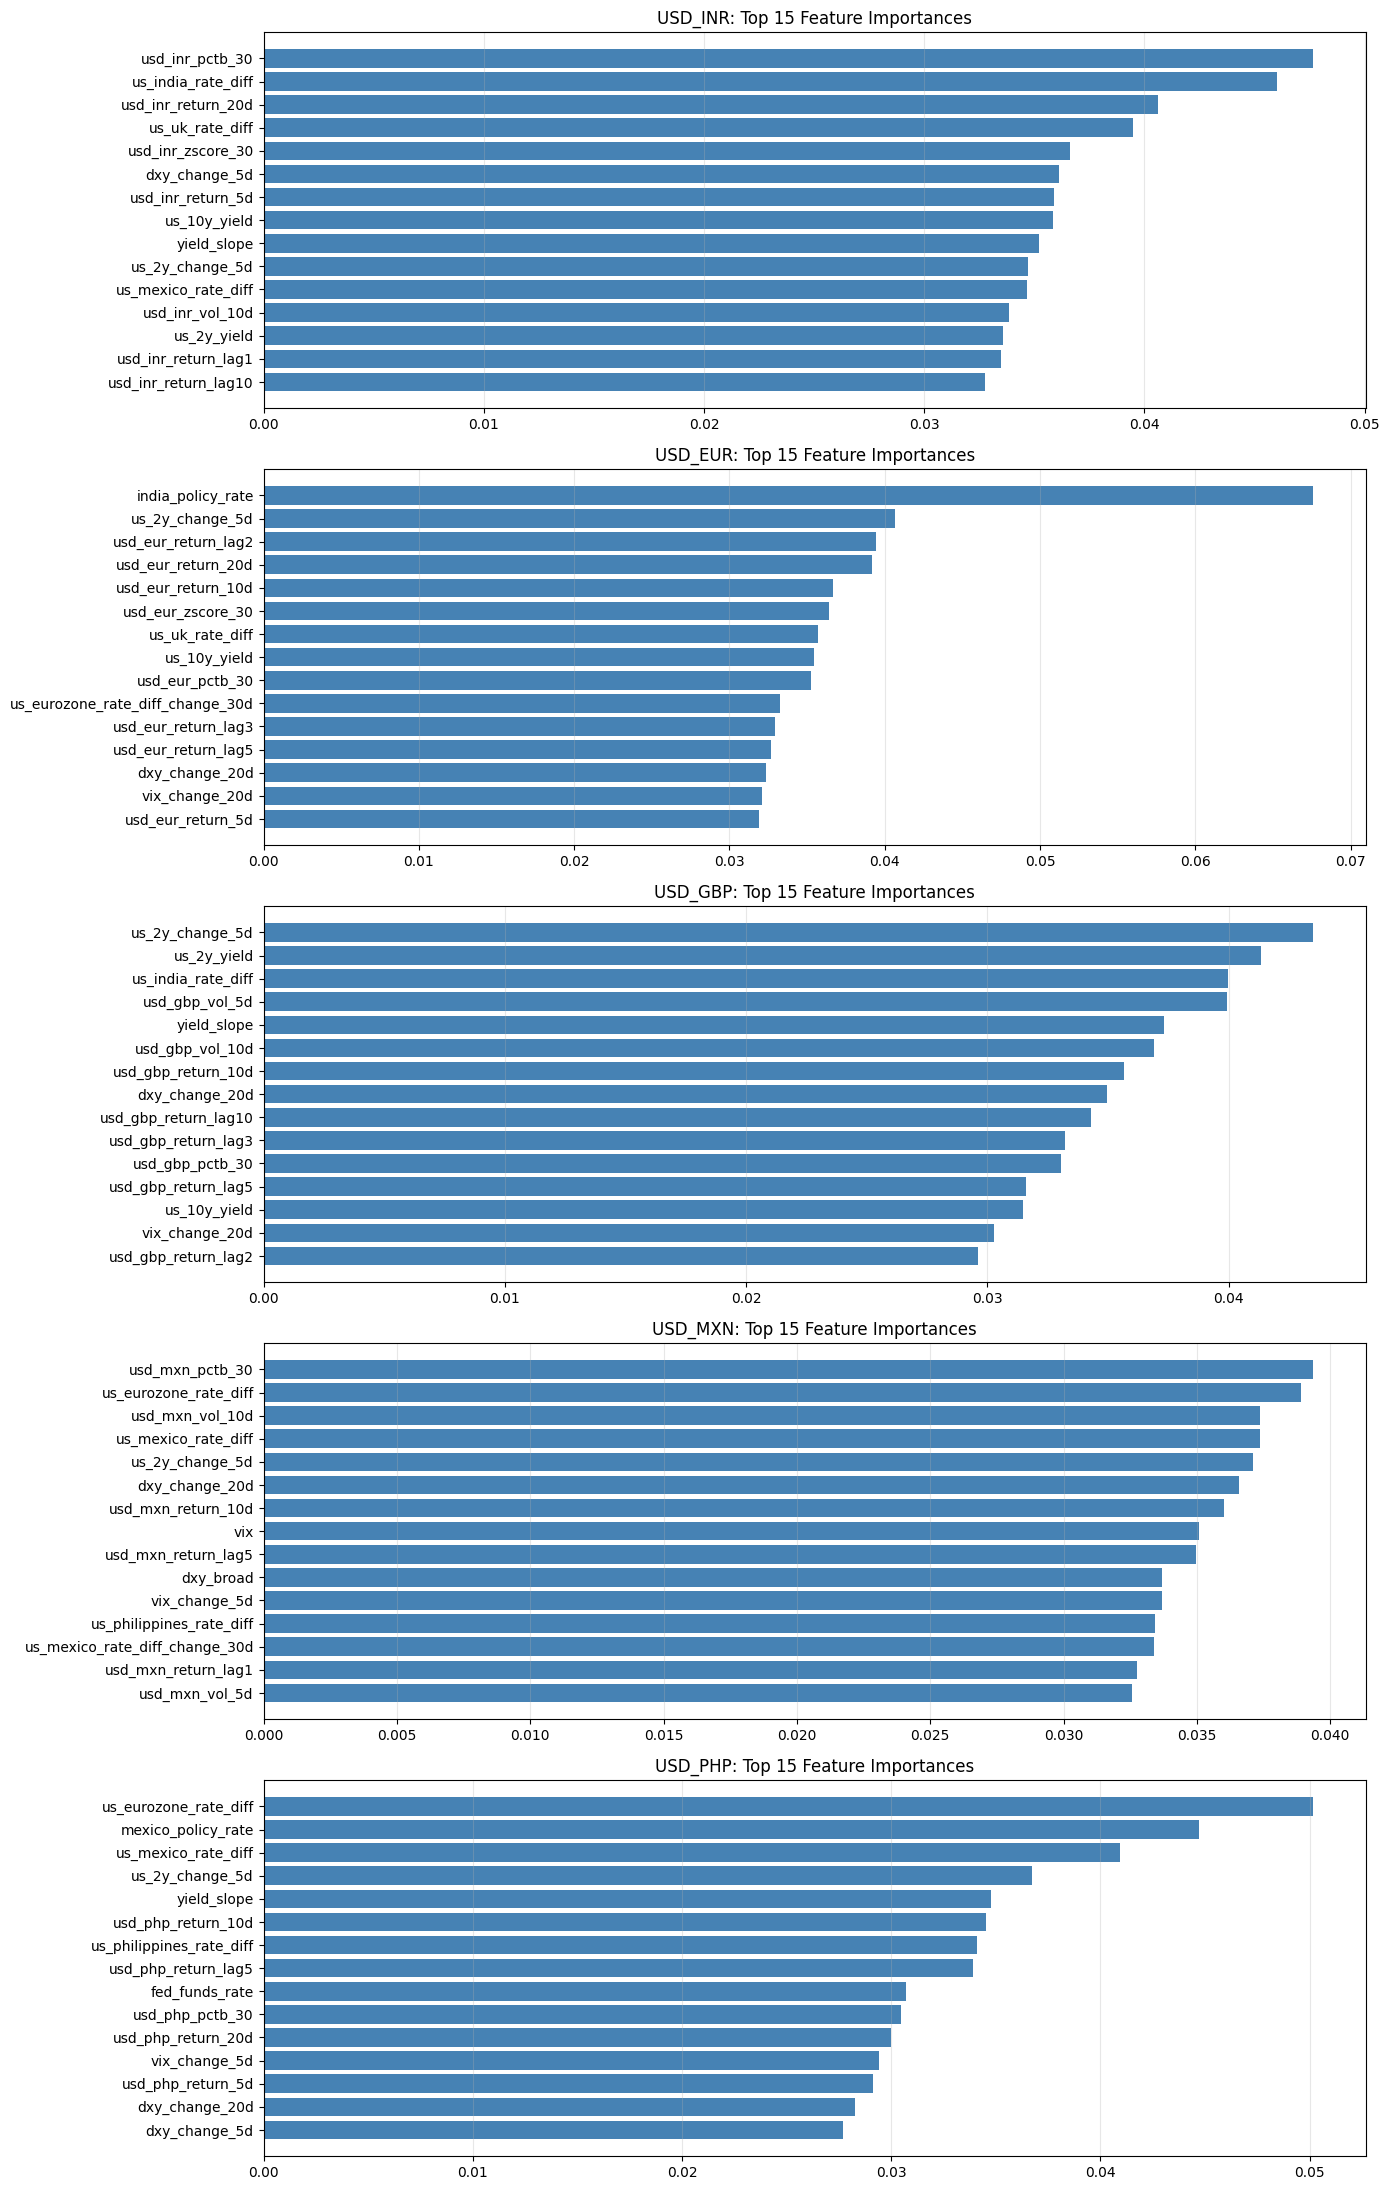

In [15]:
fig, axes = plt.subplots(5, 1, figsize=(14, 22))

for i, col in enumerate(['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']):
    if col in xgb_importances:
        importance = xgb_importances[col].head(15)
        
        axes[i].barh(importance['feature'], importance['importance'], color='steelblue')
        axes[i].set_title(f'{col.upper()}: Top 15 Feature Importances', fontsize=12)
        axes[i].invert_yaxis()
        axes[i].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print("=== Confusion Matrices (XGBoost Predictions) ===\n")

for col, result in xgb_evaluation.items():
    cm = confusion_matrix(result['actual'], result['predicted'])
    tn, fp, fn, tp = cm.ravel()
    
    precision_up = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_up = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_up = 2 * (precision_up * recall_up) / (precision_up + recall_up) if (precision_up + recall_up) > 0 else 0
    
    print(f"{col.upper()}:")
    print(f"                  Predicted")
    print(f"                  DOWN   UP")
    print(f"  Actual DOWN     {tn:>4}   {fp:>4}")
    print(f"  Actual UP       {fn:>4}   {tp:>4}")
    print(f"  Precision (UP): {precision_up*100:.1f}%   (when we say UP, we're right X% of time)")
    print(f"  Recall (UP):    {recall_up*100:.1f}%   (we catch X% of actual UP days)")
    print(f"  F1 score:       {f1_up:.3f}")
    print()

=== Confusion Matrices (XGBoost Predictions) ===

USD_INR:
                  Predicted
                  DOWN   UP
  Actual DOWN        6     17
  Actual UP         12     25
  Precision (UP): 59.5%   (when we say UP, we're right X% of time)
  Recall (UP):    67.6%   (we catch X% of actual UP days)
  F1 score:       0.633

USD_EUR:
                  Predicted
                  DOWN   UP
  Actual DOWN       11     16
  Actual UP         10     23
  Precision (UP): 59.0%   (when we say UP, we're right X% of time)
  Recall (UP):    69.7%   (we catch X% of actual UP days)
  F1 score:       0.639

USD_GBP:
                  Predicted
                  DOWN   UP
  Actual DOWN        7     20
  Actual UP          7     26
  Precision (UP): 56.5%   (when we say UP, we're right X% of time)
  Recall (UP):    78.8%   (we catch X% of actual UP days)
  F1 score:       0.658

USD_MXN:
                  Predicted
                  DOWN   UP
  Actual DOWN       13     18
  Actual UP         14     15


In [17]:
print("=== Probability Calibration ===\n")
print("When XGBoost says '70% confident UP', does it actually go UP 70% of the time?\n")

for col, result in xgb_evaluation.items():
    bins = [0, 0.3, 0.5, 0.7, 1.0]
    bin_labels = ['<30%', '30-50%', '50-70%', '>70%']
    
    result['prob_bin'] = pd.cut(result['prob_up'], bins=bins, labels=bin_labels)
    
    print(f"{col.upper()}:")
    for label in bin_labels:
        subset = result[result['prob_bin'] == label]
        if len(subset) > 0:
            actual_up_pct = (subset['actual'] == 1).mean() * 100
            print(f"  Predicted {label:>6} chance of UP → actually UP {actual_up_pct:.0f}% of the time ({len(subset)} days)")
    print()

=== Probability Calibration ===

When XGBoost says '70% confident UP', does it actually go UP 70% of the time?

USD_INR:
  Predicted   <30% chance of UP → actually UP 57% of the time (7 days)
  Predicted 30-50% chance of UP → actually UP 73% of the time (11 days)
  Predicted 50-70% chance of UP → actually UP 58% of the time (24 days)
  Predicted   >70% chance of UP → actually UP 61% of the time (18 days)

USD_EUR:
  Predicted   <30% chance of UP → actually UP 44% of the time (9 days)
  Predicted 30-50% chance of UP → actually UP 50% of the time (12 days)
  Predicted 50-70% chance of UP → actually UP 57% of the time (21 days)
  Predicted   >70% chance of UP → actually UP 61% of the time (18 days)

USD_GBP:
  Predicted   <30% chance of UP → actually UP 50% of the time (4 days)
  Predicted 30-50% chance of UP → actually UP 50% of the time (10 days)
  Predicted 50-70% chance of UP → actually UP 59% of the time (22 days)
  Predicted   >70% chance of UP → actually UP 54% of the time (24 days

In [18]:
xgb_output = {}

for col, result in xgb_evaluation.items():
    n = len(result)
    correct = int(result['correct'].sum())
    accuracy = correct / n
    p_value = 1 - stats.binom.cdf(correct - 1, n, 0.5)
    
    xgb_output[col] = {
        'model': 'xgboost_classifier',
        'test_days': n,
        'correct': correct,
        'direction_accuracy': float(accuracy),
        'p_value_vs_random': float(p_value),
        'significant_at_95': bool(p_value < 0.05),
        'predicted_up_rate': float((result['predicted'] == 1).mean()),
        'actual_up_rate': float((result['actual'] == 1).mean())
    }

with open('xgboost_results.json', 'w') as f:
    json.dump(xgb_output, f, indent=2)

print("Results saved to xgboost_results.json")
print("\nNext: notebook 08 — ETS/ARIMA classical baselines")

Results saved to xgboost_results.json

Next: notebook 08 — ETS/ARIMA classical baselines
